# Reading Stanford Digital Repository cloud formats with Python

This notebook uses each fixture PURL to discover the current file name in the Stanford Digital Repository (SDR). It then reads or displays the data directly from a Stacks URL.

Fixtures that require an authorized SDR session live in [fixtures_python_restricted.ipynb](fixtures_python_restricted.ipynb) instead of here.


## Image - single image
PURL: https://purl.stanford.edu/bc151bq1744

Note: you may need to restart the kernel to use updated packages.


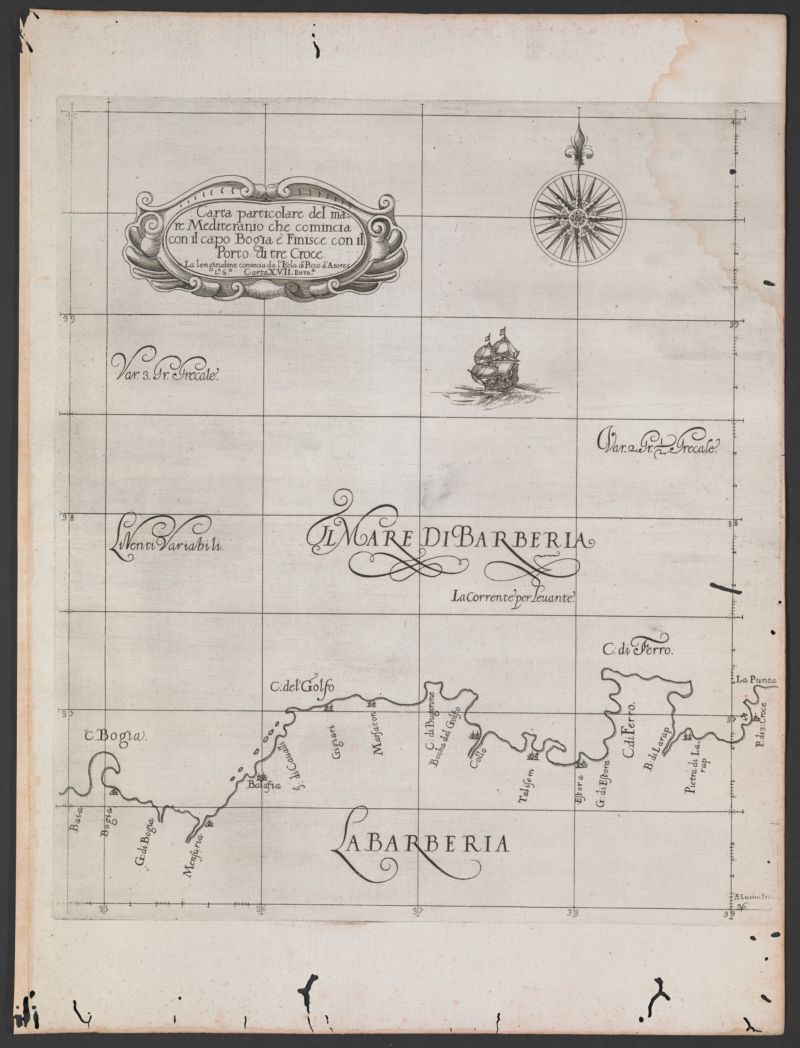

In [31]:
# Install the libraries used to request and display the IIIF image.
%pip -q install requests pillow

# The only input for this example: the SDR druid.
druid = "bc151bq1744"

# Import the library used to request the image.
import requests

# Import the notebook display helper.
from IPython.display import display

# Import Pillow's image reader.
from PIL import Image

# Import an in-memory byte stream helper.
from io import BytesIO

# Set the 1-based image number to retrieve.
image_index = 100

# Define the SDR IIIF URL with a maximum width of 1200 pixels.
image_url = (
    f"https://stacks.stanford.edu/image/iiif/"
    f"{druid}%2F{druid}_00_{image_index:04d}/full/800,/0/default.jpg" # Here, :04d formats the image_index as a 4-digit number with leading zeros if necessary
)

# Request the resized image from SDR.
response = requests.get(image_url)

# Stop with a useful error if SDR does not return the image.
response.raise_for_status()

# Open the image from the downloaded bytes.
image = Image.open(BytesIO(response.content))

# Display the IIIF image at its returned width, no larger than 800 pixels.
display(image)

## Image - multi-image
PURL: https://purl.stanford.edu/bc151bq1744

The fixture uses the same PURL as the single-image example. The IIIF manifest may contain multiple canvases; this minimal example previews the first one.

In [32]:
# Install the libraries used to request and display IIIF images.
%pip -q install requests pillow

# The only input for this example: the SDR druid.
druid = "bc151bq1744"
purl = f"https://purl.stanford.edu/{druid}"

# Import the library used to request the manifest and images.
import requests

# Import helpers for downloading thumbnails in parallel.
from concurrent.futures import ThreadPoolExecutor, as_completed

# Import the notebook display helper.
from IPython.display import display

# Import Pillow's image reader and thumbnail helpers.
from PIL import Image, ImageDraw, ImageFont, ImageOps

# Import an in-memory byte stream helper.
from io import BytesIO

# Import the ceiling and square root helpers used to size the thumbnail grid.
from math import ceil, sqrt

# Define the SDR IIIF Presentation manifest URL.
manifest_url = f"{purl}/iiif/manifest"

# Reuse one connection pool for every request in this cell.
session = requests.Session()

# Cap how long any single request may hang before failing, in seconds.
request_timeout = 10

# Request the multi-image manifest from SDR.
manifest_response = session.get(manifest_url, timeout=request_timeout)
manifest_response.raise_for_status()
manifest = manifest_response.json()
canvases = manifest["sequences"][0]["canvases"]

print(f"This manifest contains {len(canvases)} images.")

# Choose which 0-based image indexes to preview, e.g. range(0, 11) or [0, 45, 90].
preview_indices = range(0, 11)

# Keep only valid, unique indexes while preserving ascending order.
selected_indices = sorted({index for index in preview_indices if 0 <= index < len(canvases)})
print(f"Previewing {len(selected_indices)} of {len(canvases)} images: {selected_indices}")

# Reserve a fixed tile for each thumbnail and its 1-based image index.
tile_width = 220
tile_height = 250
image_area_height = 215
label_area_height = tile_height - image_area_height

# Lay the thumbnails out in a roughly square grid sized to the selected images.
grid_columns = ceil(sqrt(len(selected_indices)))
grid_rows = ceil(len(selected_indices) / grid_columns)
grid_image = Image.new("RGB", (grid_columns * tile_width, grid_rows * tile_height), "white")
grid_display = display(grid_image, display_id=True)

# Use Pillow's built-in font so the cell does not need another dependency.
label_font = ImageFont.load_default()

def draw_tile(index, thumbnail):
    tile = Image.new("RGB", (tile_width, tile_height), "white")
    tile_draw = ImageDraw.Draw(tile)

    if thumbnail is not None:
        thumbnail = thumbnail.convert("RGB")
        fitted_thumbnail = ImageOps.contain(thumbnail, (tile_width, image_area_height))
        image_x = (tile_width - fitted_thumbnail.width) // 2
        image_y = (image_area_height - fitted_thumbnail.height) // 2
        tile.paste(fitted_thumbnail, (image_x, image_y))
    else:
        tile_draw.text((10, image_area_height // 2), "Unavailable", fill="gray")

    label = f"Image {index + 1}"
    label_box = tile_draw.textbbox((0, 0), label, font=label_font)
    label_x = (tile_width - (label_box[2] - label_box[0])) // 2
    label_y = image_area_height + (label_area_height - (label_box[3] - label_box[1])) // 2
    tile_draw.text((label_x, label_y), label, fill="black", font=label_font)
    return tile


def fetch_thumbnail(index_and_canvas):
    index, canvas = index_and_canvas
    service_url = canvas["images"][0]["resource"]["service"]["@id"]
    thumbnail_url = f"{service_url}/full/{tile_width},/0/default.jpg"
    try:
        response = session.get(thumbnail_url, timeout=request_timeout)
        response.raise_for_status()
    except requests.RequestException as error:
        print(f"Thumbnail {index + 1} failed: {error}")
        return index, None
    return index, Image.open(BytesIO(response.content))

max_workers = 8
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = [
        executor.submit(fetch_thumbnail, (index, canvases[index]))
        for index in selected_indices
    ]
    for future in as_completed(futures):
        index, thumbnail = future.result()
        position = selected_indices.index(index)
        column, row = position % grid_columns, position // grid_columns
        grid_image.paste(draw_tile(index, thumbnail), (column * tile_width, row * tile_height))
        grid_display.update(grid_image)

# Preview the last selected image at full size.
page_index = selected_indices[-1]
selected_service_url = canvases[page_index]["images"][0]["resource"]["service"]["@id"]
selected_image_url = f"{selected_service_url}/full/1200,/0/default.jpg"

selected_response = session.get(selected_image_url, timeout=request_timeout)display(selected_image)

selected_response.raise_for_status()selected_image = Image.open(BytesIO(selected_response.content))

SyntaxError: invalid syntax (2508091205.py, line 116)

## Index map
PURL: https://purl.stanford.edu/kh860qj3406
Format: Shapefile

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "kh860qj3406"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/index_map.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized vector layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR index map")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## Shapefile polygons
PURL: https://purl.stanford.edu/cr288qn9438

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "cr288qn9438"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/alameda2014.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized vector layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR polygon data")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## Shapefile polygons (crosses 180 longitude)
PURL: https://purl.stanford.edu/gk831nh0251

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "gk831nh0251"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/KIR_adm0.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized vector layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR antimeridian polygon data")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## Shapefile points
PURL: https://purl.stanford.edu/bb434sw7474

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "bb434sw7474"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/gar_exp_SAU.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized point layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR point data")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## Shapefile lines
PURL: https://purl.stanford.edu/zc952cn1722

In [33]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "zc952cn1722"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/Faults_OffshoreSantaBarbara.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized line layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR line data")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## PMTiles many layers
PURL: https://purl.stanford.edu/hf224mw4004
PMTiles is a cloud-optimized tile archive. Leafmap requests only the tiles needed for the visible map.

In [34]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "hf224mw4004"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR PMTiles URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/20231116.pmtiles"

# Create a map.
map_view = Map()

# Add the cloud-optimized tile archive to the map.
layer = map_view.add_pmtiles(data_url, name="SDR PMTiles many layers")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## GeoJSON points
PURL: https://purl.stanford.edu/nz577hv6134

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "nz577hv6134"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL derived from the GeoJSON fixture.
data_url = f"https://stacks.stanford.edu/file/{druid}/samtrans_stops_20150626_20260403.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized point layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR GeoJSON points as FlatGeobuf")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## GeoJSON lines
PURL: https://purl.stanford.edu/yt111kw1413

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "yt111kw1413"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL derived from the GeoJSON fixture.
data_url = f"https://stacks.stanford.edu/file/{druid}/samTrans_bus_routes_20151021_shapes_20260406.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized line layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR GeoJSON lines as FlatGeobuf")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## GeoJSON polygons
PURL: https://purl.stanford.edu/ch787ty4618

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "ch787ty4618"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL derived from the GeoJSON fixture.
data_url = f"https://stacks.stanford.edu/file/{druid}/County_Boundary.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized polygon layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR GeoJSON polygons as FlatGeobuf")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## GeoJSON points (slow to load)
PURL: https://purl.stanford.edu/qp917dm2243

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "qp917dm2243"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR FlatGeobuf URL derived from the large GeoJSON fixture.
data_url = f"https://stacks.stanford.edu/file/{druid}/Stanford_Temperature_Model_0km.fgb"

# Create a map.
map_view = Map()

# Add the cloud-optimized point layer to the map.
layer = map_view.add_flatgeobuf(data_url, name="SDR large GeoJSON as FlatGeobuf")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## GeoTIFF (EPSG::32735)
PURL: https://purl.stanford.edu/bb223nv3920
The helper selects the SDR Cloud Optimized GeoTIFF derivative and reads it by HTTP range requests.

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "bb223nv3920"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR Cloud Optimized GeoTIFF URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/Pretoria_landcover_t1_cog.tif"

# Create a map.
map_view = Map()

# Add the COG with a color palette for raster values.
layer = map_view.add_cog(data_url, name="SDR COG EPSG:32735", colormap="viridis")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## GeoTIFF (EPSG::4326, nodata configured)
PURL: https://purl.stanford.edu/kq996gp6880

In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre

# The only input for this example: the SDR druid.
druid = "kq996gp6880"

# Import the GeoLibre map widget.
from geolibre import Map

# Define the direct SDR Cloud Optimized GeoTIFF URL.
data_url = f"https://stacks.stanford.edu/file/{druid}/SF1938_cog.tif"

# Create a map.
map_view = Map()

# Add the COG with a color palette for raster values.
layer = map_view.add_cog(data_url, name="SDR nodata COG EPSG:4326", colormap="viridis")

# Display the interactive map.
map_view

Note: you may need to restart the kernel to use updated packages.


## IIIF map with georeference annotation
PURL: https://purl.stanford.edu/bb013fz9675

This example uses Allmaps' hosted annotations API (`https://annotations.allmaps.org/?url={manifest_url}`) to look up the georeference annotation for the IIIF manifest. Allmaps also serves XYZ tiles for any annotation it hosts, which this cell renders on a GeoLibre map. An SDR-hosted annotation and XYZ tile service would be the preferred long-term Earthworks infrastructure, removing the dependency on Allmaps' hosted API.


In [ ]:
# Install GeoLibre for an interactive notebook map.
%pip -q install geolibre requests

# The only input for this example: the SDR druid.
druid = "bb013fz9675"

# Import the library used to request JSON from public web services.
import requests

# Import the notebook display helper for a clickable Allmaps Editor link.
from IPython.display import display, Markdown

# Import the GeoLibre map widget.
from geolibre import Map

# Define the SDR IIIF manifest URL for this item.
manifest_url = f"https://purl.stanford.edu/{druid}/iiif/manifest"

# Ask Allmaps' hosted API for any georeference annotation it has for this manifest.
# Pass the manifest as a params value so requests URL-encodes it correctly.
annotation_response = requests.get("https://annotations.allmaps.org/", params={"url": manifest_url})

# Stop with a useful error if Allmaps itself is unreachable.
annotation_response.raise_for_status()

# Read any georeference annotations Allmaps already has for this manifest.
annotations = annotation_response.json().get("items", [])

if not annotations:
    # Build a clickable Allmaps Editor link so a new georeferencing session can be started.
    editor_url = f"https://editor.allmaps.org/#/collection?url={manifest_url}"
    display(Markdown(
        f"No Allmaps georeference annotation was found for this manifest.\n\n"
        f"Start one in the [Allmaps Editor]({editor_url})."
    ))
else:
    # Read the first annotation, whose id embeds the Allmaps map ID.
    annotation = annotations[0]
    map_id = annotation["id"].rsplit("/", 1)[-1]

    # Build the Allmaps XYZ tile URL template for the georeferenced map.
    tile_url = f"https://allmaps.xyz/maps/{map_id}/{{z}}/{{x}}/{{y}}.png"

    # The annotation body is already a GeoJSON FeatureCollection of ground control points.
    gcp_geojson = annotation["body"]

    # Create a map.
    map_view = Map()

    # Add the Allmaps XYZ tile layer to the map.
    map_view.add_tile_layer(tile_url, name="Allmaps georeferenced map")

    # Add the annotation's ground control points so the georeferencing extent is visible.
    gcp_layer = map_view.add_geojson(gcp_geojson, name="Allmaps ground control points")



    # Display the interactive map.    display(map_view)

Note: you may need to restart the kernel to use updated packages.
